In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
df = pd.read_csv("cleaned_retail.csv")

In [7]:
df = pd.read_parquet("cleaned_retail.parquet")

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407650 entries, 0 to 407649
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407650 non-null  int64         
 1   StockCode    407650 non-null  object        
 2   Description  407650 non-null  object        
 3   Quantity     407650 non-null  Int64         
 4   InvoiceDate  407650 non-null  datetime64[ns]
 5   Price        407650 non-null  float64       
 6   Customer ID  407650 non-null  object        
 7   Country      407650 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 25.3+ MB


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['Price']

# Set reference date (1 day after the last purchase)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM DataFrame
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Display first 5 rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [13]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4312 non-null   object 
 1   Recency     4312 non-null   int64  
 2   Frequency   4312 non-null   int64  
 3   Monetary    4312 non-null   Float64
dtypes: Float64(1), int64(2), object(1)
memory usage: 139.1+ KB


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.0
mean,91.171846,4.455705,2048.238233
std,96.860633,8.170213,8914.481278
min,1.000000,1.000000,2.95
25%,18.000000,1.000000,307.9875
50%,53.000000,2.000000,706.02
75%,136.000000,5.000000,1723.1425
max,374.000000,205.000000,349164.35


In [15]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Initialize StandardScaler
scaler = StandardScaler()

# Normalize the RFM values
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame (recommended)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

# Display first 5 rows
rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.762299,0.801087,-0.187961
1,-0.910402,-0.300603,-0.081329
2,-0.177305,-0.423013,-0.204868
3,-0.497389,-0.178193,0.069883
4,-0.827799,-0.423013,-0.196031


In [16]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,5.602610e-17,5.932175e-17,-2.306957e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.310522e-01,-4.230129e-01,-2.294610e-01
25%,-7.555219e-01,-4.230129e-01,-1.952388e-01
50%,-3.941361e-01,-3.006029e-01,-1.505835e-01
75%,4.628645e-01,6.662716e-02,-3.647250e-02
max,2.920288e+00,2.454863e+01,3.894297e+01


In [17]:
rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.762299,0.801087,-0.187961
1,-0.910402,-0.300603,-0.081329
2,-0.177305,-0.423013,-0.204868
3,-0.497389,-0.178193,0.069883
4,-0.827799,-0.423013,-0.196031


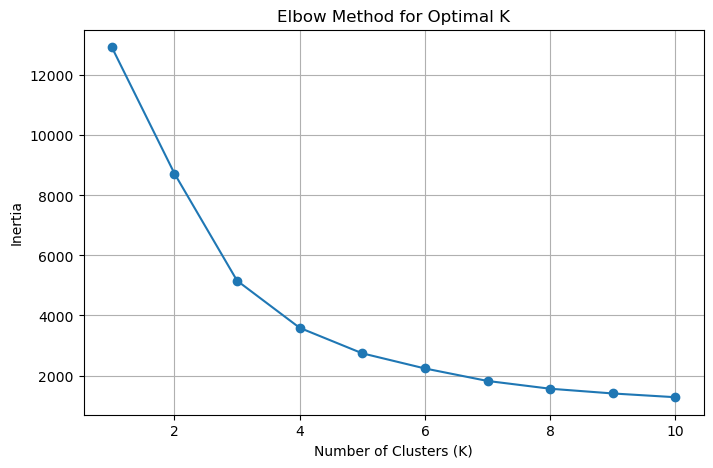

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia values
inertia = []

# Test K values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [19]:
n_clusters = 4

In [20]:
from sklearn.cluster import KMeans

# Create K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first few rows
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,165,11,372.86,1
1,12347.0,3,2,1323.32,0
2,12348.0,74,1,222.16,0
3,12349.0,43,3,2671.14,0
4,12351.0,11,1,300.93,0


In [21]:
rfm['Cluster'].value_counts()

Cluster
0    3201
1    1047
3      59
2       5
Name: count, dtype: int64

In [22]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.069978,4.433302,1710.796373
1,242.976122,1.659981,596.884489
2,5.600000,113.600000,215543.67
3,14.271186,46.033898,28018.434915


In [23]:
segment_map = {
    0: 'Regular Customers',
    1: 'At-Risk Customers',
    2: 'VIP Customers',
    3: 'Loyal Customers'
}

rfm['CustomerSegment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,CustomerSegment
0,12346.0,165,11,372.86,1,At-Risk Customers
1,12347.0,3,2,1323.32,0,Regular Customers
2,12348.0,74,1,222.16,0,Regular Customers
3,12349.0,43,3,2671.14,0,Regular Customers
4,12351.0,11,1,300.93,0,Regular Customers


In [24]:
rfm.to_csv("customer_segments.csv", index=False)

print("Customer segmentation file saved successfully!")

Customer segmentation file saved successfully!
